# RavenStack SaaS Churn Analytics

## 1 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


ModuleNotFoundError: No module named 'pandas'

## 2. Load Data

In [2]:
accounts = pd.read_csv("../data/ravenstack_accounts.csv")
churn_events = pd.read_csv("../data/ravenstack_churn_events.csv")
feature_usage = pd.read_csv("../data/ravenstack_feature_usage.csv")
subscriptions = pd.read_csv("../data/ravenstack_subscriptions.csv")
support_tickets = pd.read_csv("../data/ravenstack_support_tickets.csv")

## 3. Dataset Overview

In [7]:
print("Accounts: ",accounts.shape)
print("Churn_Events: ",churn_events.shape)
print("Feautre_Usage: ",feature_usage.shape)
print("Subscriptions: ",subscriptions.shape)
print("Support_Ticket: ",support_tickets.shape)

Accounts:  (500, 10)
Churn_Events:  (600, 9)
Feautre_Usage:  (25000, 8)
Subscriptions:  (5000, 14)
Support_Ticket:  (2000, 9)


In [8]:
accounts.info()
subscriptions.info()
feature_usage.info()
support_tickets.info()
churn_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   start_date         5000 non-null   st

## 4. Account Analysis

In [52]:
accounts.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB


In [51]:
accounts.columns

Index(['account_id', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag'],
      dtype='str')

In [53]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [14]:
accounts["industry"].value_counts()

industry
DevTools         113
FinTech          112
Cybersecurity    100
HealthTech        96
EdTech            79
Name: count, dtype: int64

Key Observation: RavenStack's customer base is concentrated in technology-oriented industries,
with DevTools and FinTech representing the largest segments.
Cybersecurity, Healthcare, and EdTech also contribute significantly,
indicating broad adoption across digital-first businesses.

In [15]:
accounts["country"].value_counts()

country
US    291
UK     58
IN     49
AU     32
DE     25
CA     23
FR     22
Name: count, dtype: int64

Key Observstion: The United States represents the largest share of RavenStack customers,
suggesting that the company's primary market is currently concentrated in North America.
This may indicate opportunities for international expansion.

In [16]:
accounts["plan_tier"].value_counts()

plan_tier
Pro           178
Basic         168
Enterprise    154
Name: count, dtype: int64

Key Observation: Customer adoption is relatively balanced across Basic, Pro, and Enterprise plans,
although the Pro plan has the highest share.
This suggests that customers perceive value across multiple pricing tiers rather than concentrating in a single offering.

In [17]:
accounts["churn_flag"].value_counts()

churn_flag
False    390
True     110
Name: count, dtype: int64

In [26]:
print(accounts.nunique())

account_id         500
account_name       500
industry             5
country              7
signup_date        370
referral_source      5
plan_tier            3
seats               73
is_trial             2
churn_flag           2
dtype: int64


Key Observation: Approximately 22% of accounts have churned,
while 78% remain active.
This indicates that churn is a meaningful business challenge and justifies predictive churn modeling.

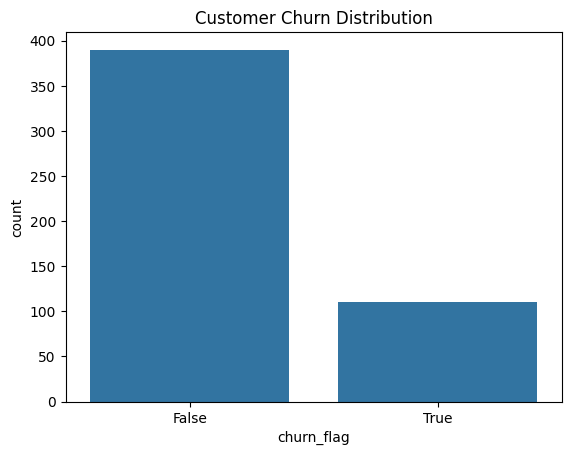

In [19]:
sns.countplot(data=accounts, x="churn_flag")
plt.title("Customer Churn Distribution")
plt.show()

## 5. Subscription Analysis

In [22]:
subscriptions["plan_tier"].value_counts()

plan_tier
Enterprise    1723
Pro           1675
Basic         1602
Name: count, dtype: int64

Key Observation: Enterprise is the most adopted subscription tier, indicating that RavenStack successfully attracts larger customers willing to pay for premium functionality.

In [23]:
subscriptions["billing_frequency"].value_counts()

billing_frequency
monthly    2539
annual     2461
Name: count, dtype: int64

Key Observation: Customer preference is relatively balanced between monthly and annual billing, with a slight preference toward monthly subscriptions.

In [24]:
subscriptions["upgrade_flag"].value_counts()

upgrade_flag
False    4471
True      529
Name: count, dtype: int64

Key Observation: Most customers remain on their chosen subscription tier, suggesting limited plan movement after initial purchase.

In [25]:
subscriptions["downgrade_flag"].value_counts()

downgrade_flag
False    4782
True      218
Name: count, dtype: int64

Key Observation: Plan downgrades occur infrequently, indicating relatively stable subscription behavior.

In [27]:
subscriptions["auto_renew_flag"].value_counts()

auto_renew_flag
True     4005
False     995
Name: count, dtype: int64

Key Observation: Most customers enable auto-renew.

In [28]:
subscriptions[["mrr_amount","arr_amount"]].describe()


,mrr_amount,arr_amount
count,5000.000000,5000.000000
mean,2267.749400,27212.992800
std,3421.375348,41056.504178
min,0.000000,0.000000
25%,285.000000,3420.000000
50%,931.000000,11172.000000
75%,2786.000000,33432.000000
max,33830.000000,405960.000000


Average MRR = $2,267
Average ARR = $27,212

## 6. Support-Tickets Analysis

In [29]:
support_tickets["priority"].value_counts()

priority
urgent    514
high      510
medium    491
low       485
Name: count, dtype: int64

Key Observation: Unusual Pattern, as most of the tickets are urgently prioritized. 

In [30]:
support_tickets["escalation_flag"].value_counts()

escalation_flag
False    1905
True       95
Name: count, dtype: int64

Key Observation: Despite of really high number of urgent priority tickets, relatively few are escalated.

In [31]:
support_tickets["satisfaction_score"].describe()

count    1175.000000
mean        3.981277
std         0.809646
min         3.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: satisfaction_score, dtype: float64

Key Observation: A 3.9 average score suggest a positive response from the customer, while there's still room for improvement aiming for 4.5+ average ratings.

In [32]:
support_tickets["resolution_time_hours"].describe()

count    2000.000000
mean       35.861000
std        21.138427
min         1.000000
25%        17.000000
50%        35.000000
75%        54.000000
max        72.000000
Name: resolution_time_hours, dtype: float64

Key Observations: Support tickets take approximately 1.5 days to resolve on average.

## 7. Feature-Usage Analysis

In [33]:
feature_usage["feature_name"].value_counts().head(10)

feature_name
feature_12    659
feature_32    659
feature_6     655
feature_17    651
feature_34    650
feature_26    649
feature_36    648
feature_31    644
feature_20    643
feature_24    643
Name: count, dtype: int64

In [34]:
feature_usage["is_beta_feature"].value_counts()

is_beta_feature
False    22456
True      2544
Name: count, dtype: int64

Key Observation: about 10% of usage activity involves beta features.(Indicates: experimentation and customer adoptability.)

In [35]:
feature_usage["usage_count"].describe()

count    25000.000000
mean        10.021000
std          3.143729
min          0.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         26.000000
Name: usage_count, dtype: float64

Key Observation: A user on an average interact with platform features approximately 10 times per session, indicates moderate product engagement. 

In [37]:
feature_usage["usage_duration_secs"].describe()

count    25000.000000
mean      3042.202880
std       2056.544615
min          0.000000
25%       1350.000000
50%       2760.000000
75%       4400.000000
max      12696.000000
Name: usage_duration_secs, dtype: float64

Key Observation: A user spends around 50 mintues on an average on the platform per session. This Suggests Ravenstack is actively used platform rather than a passive tool.

In [38]:
feature_usage["error_count"].describe()

count    25000.000000
mean         0.564280
std          1.012595
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          8.000000
Name: error_count, dtype: float64

Key Observation: Users Encounter Least ot relatively very few errors during the product usage, suggesting a stable and reliable platform experience.

## 8. Churn Events Analysis

In [39]:
churn_events["reason_code"].value_counts()

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64

Key Observation: The leading cause of churn are the producr features and support-related issues, which also includes customer retention challenges driven by rpoduct experience rather than pricing.

In [40]:
churn_events["is_reactivation"].value_counts()

is_reactivation
False    539
True      61
Name: count, dtype: int64

Key Observation: Approximately 10% of the customers return eventuslly to the platform. This suggest an opportunities to win them back.

In [41]:
churn_events["preceding_upgrade_flag"].value_counts()

preceding_upgrade_flag
False    477
True     123
Name: count, dtype: int64

Key Observation: The customers tend to churn after a plan upgrade. High possibilities that the customers expected more from the product that the product failed to deliever.

In [42]:
churn_events["preceding_downgrade_flag"].value_counts()

preceding_downgrade_flag
False    547
True      53
Name: count, dtype: int64

Key Observation: Downgrade appears before churns but not in majority of the cases. It can be considered as a potential sign but not a strongest alias.

In [43]:
churn_events["refund_amount_usd"].describe()

count    600.000000
mean      14.420417
std       39.224591
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      392.920000
Name: refund_amount_usd, dtype: float64

Key Observation: The Data suggest that most custr=omers didnt receive their refunds(median = 0 & 75th percentile = 0). 
Refunds are often considered uncommon, with most churns leading to no financial reimbursement.

## 9. Data Quality Assessment

In [45]:
accounts.isnull().sum()

account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

In [47]:
subscriptions.isnull().sum()

subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64

In [48]:
feature_usage.isnull().sum()

usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64

In [49]:
support_tickets.isnull().sum()

ticket_id                        0
account_id                       0
submitted_at                     0
closed_at                        0
resolution_time_hours            0
priority                         0
first_response_time_minutes      0
satisfaction_score             825
escalation_flag                  0
dtype: int64

In [50]:
churn_events.isnull().sum()

churn_event_id                0
account_id                    0
churn_date                    0
reason_code                   0
refund_amount_usd             0
preceding_upgrade_flag        0
preceding_downgrade_flag      0
is_reactivation               0
feedback_text               148
dtype: int64

In [54]:
print("Accounts: ",accounts.duplicated().sum())
print("Subscriptions: ",subscriptions.duplicated().sum())
print("Feautre_Usage: ",feature_usage.duplicated().sum())
print("Support_Ticket: ",support_tickets.duplicated().sum())
print("Churn_Events: ",churn_events.duplicated().sum())

Accounts:  0
Subscriptions:  0
Feautre_Usage:  0
Support_Ticket:  0
Churn_Events:  0


## 10. Data Type Conversion

In [55]:
print(accounts.head(3))
print(subscriptions.head(3))

  account_id account_name  industry country signup_date referral_source  \
0   A-2e4581    Company_0    EdTech      US  2024-10-16         partner   
1   A-43a9e3    Company_1   FinTech      IN  2023-08-17           other   
2   A-0a282f    Company_2  DevTools      US  2024-08-27         organic   

  plan_tier  seats  is_trial  churn_flag  
0     Basic      9     False       False  
1     Basic     18     False        True  
2     Basic      1     False       False  
  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17   
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62   

   mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag  \
0        2786       33432     False         False           False        True   
1         833        9996     False         False           Fals

In [56]:
accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])

In [57]:
accounts.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   account_id       500 non-null    str           
 1   account_name     500 non-null    str           
 2   industry         500 non-null    str           
 3   country          500 non-null    str           
 4   signup_date      500 non-null    datetime64[us]
 5   referral_source  500 non-null    str           
 6   plan_tier        500 non-null    str           
 7   seats            500 non-null    int64         
 8   is_trial         500 non-null    bool          
 9   churn_flag       500 non-null    bool          
dtypes: bool(2), datetime64[us](1), int64(1), str(6)
memory usage: 32.4 KB


In [58]:
accounts.head(10)

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True
5,A-1b9609,Company_5,EdTech,IN,2023-10-12,ads,Enterprise,4,False,False
6,A-a0ca4e,Company_6,Cybersecurity,US,2024-03-08,ads,Pro,11,False,False
7,A-e5d6ab,Company_7,EdTech,US,2023-04-15,partner,Pro,3,False,False
8,A-7dacce,Company_8,Cybersecurity,CA,2024-09-10,event,Enterprise,12,False,True
9,A-10b8da,Company_9,DevTools,US,2023-05-08,partner,Enterprise,14,False,True


In [59]:
accounts["signup_date"].dt.year.head()

0    2024
1    2023
2    2024
3    2023
4    2024
Name: signup_date, dtype: int32

In [60]:
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])

In [64]:
subscriptions["start_date"].dt.year.head()

0    2023
1    2024
2    2024
3    2024
4    2024
Name: start_date, dtype: int32

In [65]:
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])

In [68]:
subscriptions.head(10)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True
5,S-4b9b13,A-fa2041,2024-08-13,NaT,Pro,15,735,8820,False,False,False,False,monthly,True
6,S-dceac6,A-417d2f,2023-12-30,NaT,Enterprise,4,796,9552,False,False,False,False,annual,True
7,S-8cad7b,A-5f2961,2024-12-23,NaT,Basic,16,304,3648,False,False,False,False,annual,True
8,S-24796e,A-cc8c8f,2024-11-27,NaT,Enterprise,23,4577,54924,False,False,False,False,annual,False
9,S-d0c344,A-80eeb6,2024-10-27,NaT,Pro,22,1078,12936,False,False,False,False,annual,False


In [69]:
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

In [70]:
support_tickets["submitted_at"] = pd.to_datetime(support_tickets["submitted_at"])

In [71]:
support_tickets["closed_at"] = pd.to_datetime(support_tickets["closed_at"])

In [72]:
churn_events["churn_date"] = pd.to_datetime(churn_events["churn_date"])

In [77]:
churn_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   churn_event_id            600 non-null    str           
 1   account_id                600 non-null    str           
 2   churn_date                600 non-null    datetime64[us]
 3   reason_code               600 non-null    str           
 4   refund_amount_usd         600 non-null    float64       
 5   preceding_upgrade_flag    600 non-null    bool          
 6   preceding_downgrade_flag  600 non-null    bool          
 7   is_reactivation           600 non-null    bool          
 8   feedback_text             452 non-null    str           
dtypes: bool(3), datetime64[us](1), float64(1), str(4)
memory usage: 30.0 KB


## 11. Exploratory Data Analysis

In [3]:
industry_churn  = pd.crosstab(
        accounts["industry"],
        accounts["churn_flag"]
)

industry_churn

churn_flag,False,True
industry,,
Cybersecurity,84,16
DevTools,78,35
EdTech,66,13
FinTech,87,25
HealthTech,75,21


In [29]:
industry_churn_rate = pd.crosstab(
    accounts["industry"],
    accounts["churn_flag"],
    normalize="index"
)*100

industry_churn_rate

churn_flag,False,True
industry,,
Cybersecurity,84.000000,16.000000
DevTools,69.026549,30.973451
EdTech,83.544304,16.455696
FinTech,77.678571,22.321429
HealthTech,78.125000,21.875000


In [5]:
industry_churn_rate.sort_values(
    by=True,
    ascending=False
)

churn_flag,False,True
industry,,
DevTools,69.026549,30.973451
FinTech,77.678571,22.321429
HealthTech,78.125000,21.875000
EdTech,83.544304,16.455696
Cybersecurity,84.000000,16.000000


<Axes: title={'center': 'Churn Rate by Industry (%)'}, xlabel='industry'>

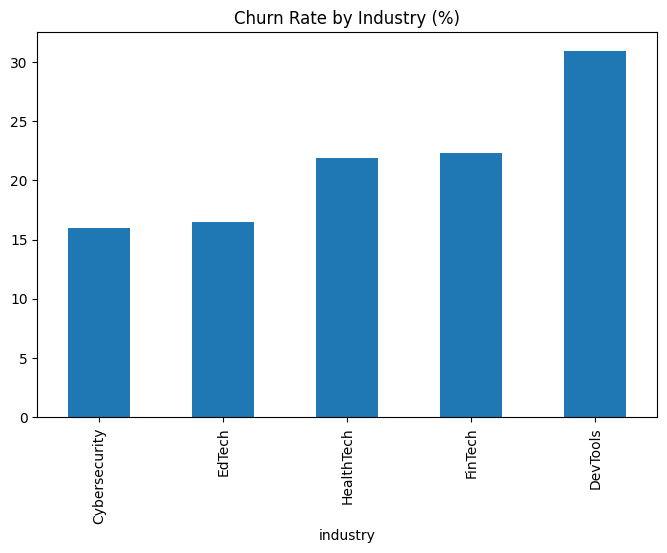

In [6]:
industry_churn_rate[True].sort_values().plot(
    kind="bar",
    figsize=(8,5),
    title="Churn Rate by Industry (%)"
)

Initial Insight: 
- The churn rates were analyzed through noramlised churn rates rather than counts to get the better business inights.
- The analysis reveals that Devtools industry exhibits the highest churn rates, while cybersecurity demonstrates the lowest rates.
- This analysis also demonstrated the importance of churn rates over churn counts when an individual need real business insights, becuase counts can often lead to misleading conclusions as the customer counts for every industries may not be same.
- This also teels us that the customer retention is a major challenge within the DevTools industry and further investigation could be done for the organisation's betterment.

In [24]:
subscriptions_with_industry = subscriptions.merge(
    accounts[["account_id","industry"]],
    on="account_id"
)

In [25]:
industry_revenue = subscriptions_with_industry.groupby(
    "industry")["arr_amount"].sum().sort_values(ascending=False)

industry_revenue

industry
FinTech          32033952
DevTools         28843848
Cybersecurity    27039816
EdTech           24518004
HealthTech       23629344
Name: arr_amount, dtype: int64

<Axes: title={'center': 'Total ARR by Industry'}, xlabel='industry'>

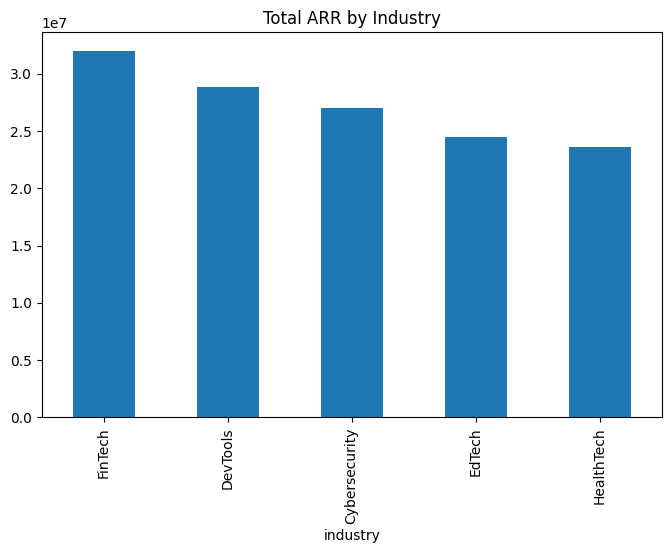

In [9]:
industry_revenue.plot(
    kind="bar",
    figsize=(8,5),
    title="Total ARR by Industry"
)

In [13]:
billing_churn = subscriptions[["account_id","billing_frequency"]].merge(
    accounts[["account_id","churn_flag"]],
    on="account_id"
)
billing_churn

,account_id,billing_frequency,churn_flag
0,A-3c1a3f,monthly,False
1,A-9b9fe9,monthly,False
2,A-659280,annual,True
3,A-e7a1e2,monthly,False
4,A-ba6516,monthly,False
...,...,...,...
4995,A-fa2041,monthly,False
4996,A-db5e9e,monthly,False
4997,A-443f6f,annual,False
4998,A-c7ffc2,monthly,False


In [14]:
pd.crosstab(
    billing_churn["billing_frequency"],
    billing_churn["churn_flag"],
    normalize="index"
) * 100

churn_flag,False,True
billing_frequency,,
annual,77.570093,22.429907
monthly,77.156361,22.843639


Observations: 
- The analysis reveals that monthly subscribers(22.84%) have a slight higher churn rate compared to annual subscribers(22.43%).
- However, the difference is less than 1 percent so "billing frequency" alone cant be a strong predictor of customer churn within the organisation.
- Further other aspects such as feature adoption, customer satisfaction etc are likely to have greater impact.
- ****very important: Statistical  Difference != Business Difference

In [3]:
tickets_per_account = support_tickets.groupby(
    "account_id"
).size().reset_index(name="ticket_count")

tickets_per_account.head()

,account_id,ticket_count
0,A-00bed1,4
1,A-00cac8,2
2,A-0158bb,1
3,A-016043,3
4,A-019782,2


In [4]:
ticket_churn = tickets_per_account.merge(
    accounts[["account_id","churn_flag"]],
    on="account_id"
)
ticket_churn.head()

,account_id,ticket_count,churn_flag
0,A-00bed1,4,False
1,A-00cac8,2,False
2,A-0158bb,1,False
3,A-016043,3,False
4,A-019782,2,False


In [5]:
ticket_churn.groupby("churn_flag")["ticket_count"].mean()

churn_flag
False    4.083333
True     4.000000
Name: ticket_count, dtype: float64

Key Observation: According to the data, churned customers are approximately equal to retained customers. That implies, When a business says customer leaves because of support does not mean that customers who open more tickets leave more often. 
This cannot be a high priority insight to determine the Churn rate. 

In [6]:
satisfaction_churn = support_tickets.merge(
    accounts[["account_id","churn_flag"]],
    on="account_id"
)

In [7]:
satisfaction_churn.groupby(
    "churn_flag"
)["satisfaction_score"].mean()

churn_flag
False    3.972678
True     4.011538
Name: satisfaction_score, dtype: float64

Key Observation: The satisfaction score were nearly identical between churned and reatined customers(A small difference of 0.04).
This suggests satisfaction score alone is not a strong indicator of churn within Ravenstack dataset.

In [9]:
usage_churn = (
    feature_usage
    .merge(
        subscriptions[["subscription_id","account_id"]],
        on="subscription_id"
    )
    .merge(
        accounts[["account_id","churn_flag"]],
        on="account_id"
    )
)

In [10]:
usage_churn.groupby("churn_flag")["usage_count"].mean()

churn_flag
False    10.018210
True     10.030393
Name: usage_count, dtype: float64

Key Observation: The feature Usage count is almost similar between the churned users and retained users. This cant be considered a strong factors to indicate the churn within Ravenstack dataset.

In [11]:
industry_churn_counts = pd.crosstab(
    accounts["industry"],
    accounts["churn_flag"]
)
industry_churn_counts

churn_flag,False,True
industry,,
Cybersecurity,84,16
DevTools,78,35
EdTech,66,13
FinTech,87,25
HealthTech,75,21


In [14]:
industry_churn_counts[True].sort_values(
    ascending=False
)

industry
DevTools         35
FinTech          25
HealthTech       21
Cybersecurity    16
EdTech           13
Name: True, dtype: int64

<Axes: title={'center': 'Number of Churned Customers by Industries'}, xlabel='industry'>

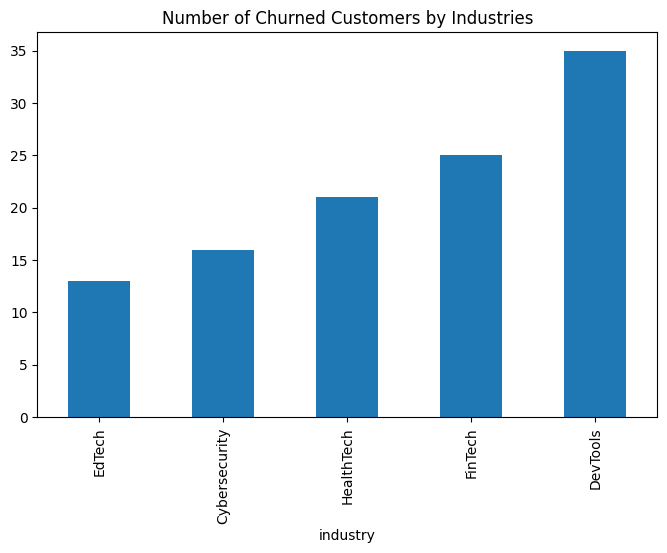

In [15]:
industry_churn_counts[True].sort_values().plot(
    kind="bar",
    figsize=(8,5),
    title="Number of Churned Customers by Industries"
)

### DevTools Segment Retention Risk

The DevTools industry segment exhibits both the highest churn count and the highest churn rate among all customer segments.

This indicates that customer retention challenges are concentrated within the DevTools market rather than being evenly distributed across industries.

Further investigation should focus on understanding product adoption, feature expectations, and competitive pressures within the DevTools segment to improve retention performance.


<Axes: title={'center': 'Churned Customers by Industry'}, ylabel='industry'>

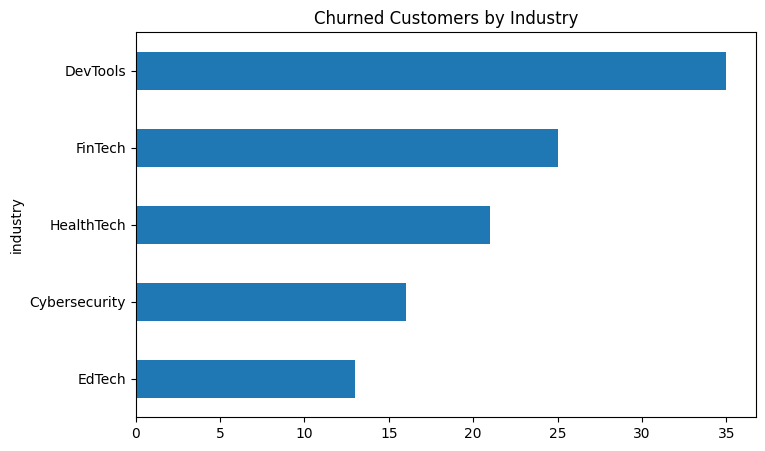

In [21]:
industry_churn_counts[True].sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Churned Customers by Industry"
)

<Axes: title={'center': 'Total ARR by Industry'}, ylabel='industry'>

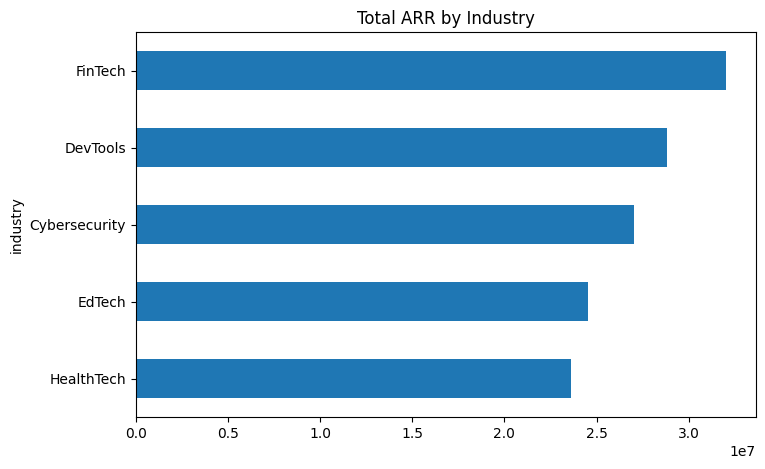

In [27]:
industry_revenue.sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Total ARR by Industry"
)

<Axes: title={'center': 'Churn Rate by Industry (%)'}, ylabel='industry'>

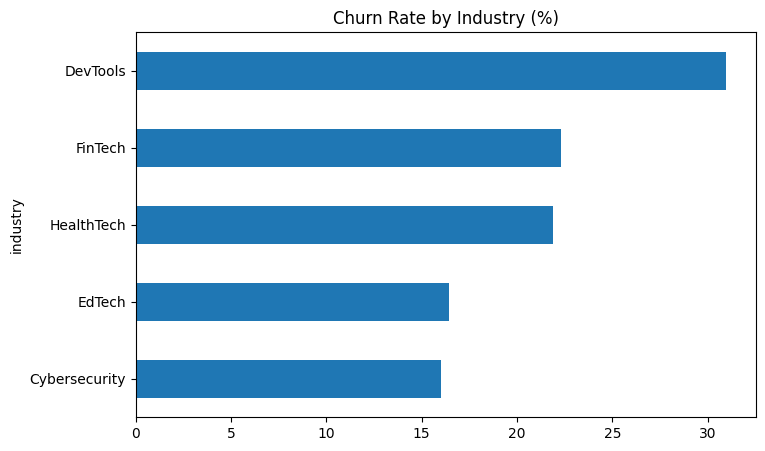

In [31]:
industry_churn_rate[True].sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Churn Rate by Industry (%)"
)

In [32]:
subscriptions.groupby("plan_tier")["arr_amount"].sum().sort_values(ascending=False)

plan_tier
Enterprise    101678652
Pro            25261068
Basic           9125244
Name: arr_amount, dtype: int64

Key Observation: 
- Enterprise subscriptions genarates over 101 million dollars in ARR, contributing to the revenue the most for Ravenstack's Revenue. 
- While the other two plans contribute to the revenue significantly low.
- It also implies that a potential businesss risk as the larger portion of revenue depends/relies on a single plan tier.

In [35]:
plan_churn = pd.crosstab(
    accounts["plan_tier"],
    accounts["churn_flag"],
    normalize="index"
) * 100

plan_churn

churn_flag,False,True
plan_tier,,
Basic,77.976190,22.023810
Enterprise,77.922078,22.077922
Pro,78.089888,21.910112


In [36]:
plan_churn[True].sort_values(ascending=False)

plan_tier
Enterprise    22.077922
Basic         22.023810
Pro           21.910112
Name: True, dtype: float64

### Churn Rate by Plan Tier

Churn rates were nearly identical across all plan tiers.

* Enterprise: 22.08%
* Basic: 22.02%
* Pro: 21.91%

The differences were less than 0.2 percentage points, indicating that plan tier is not a significant driver of churn within the RavenStack dataset.

While Enterprise customers generate the majority of ARR, they do not exhibit materially different retention behavior compared to Basic or Pro customers.


In [39]:
accounts_subs = subscriptions.merge(
    accounts[["account_id","country"]],
    on="account_id"
)

country_revenue = accounts_subs.groupby(
    "country"
)["arr_amount"].sum().sort_values(ascending=False)

country_revenue

country
US    79615140
UK    14645652
IN    14331900
AU    10079760
FR     7077552
CA     5730744
DE     4584216
Name: arr_amount, dtype: int64

Key Observation =
- Us is not leading its dominating the RavenStakc's Revenue by approximately % of the total ARR.
- UK and India are the second largest revenue contibutors.
- This can imply that RavenStakc shall hevaily ocncentrate in the US Market.
- This indicates that RavenStack's growth is heavily concentrated in the US market. While this creates a strong revenue foundation, it also introduces geographic concentration risk and highlights opportunities for international expansion.

##  Key Findigns

### 1. Customer Segment Analysis

DevTools customers exhibited the highest churn rate among all industries, indicating a potential retention challenge within this segment. In contrast, Cybersecurity customers demonstrated the lowest churn rate, making them the most stable customer group.

### 2. Revenue Analysis

FinTech emerged as the highest revenue-generating industry. At the subscription level, Enterprise plans contributed the majority of Annual Recurring Revenue (ARR), while the United States accounted for the largest share of total revenue among all countries.

### 3. Churn Driver Assessment

Multiple factors were tested as potential churn drivers, including plan tier, billing frequency, support ticket volume, customer satisfaction scores, and overall feature usage. The analysis found no significant relationship between these variables and customer churn, suggesting they are not strong predictors of retention within the RavenStack dataset.

### 4. Geographic Revenue Concentration Risk

A significant portion of total ARR originates from the United States market. While this demonstrates strong market penetration, it also creates geographic concentration risk, as revenue performance is heavily dependent on a single country.

### 5. Revenue and Retention Opportunity

Cybersecurity customers represent a particularly attractive segment due to their combination of strong retention and substantial revenue contribution. Expanding acquisition and retention efforts within this industry could provide sustainable long-term growth for RavenStack.

### 6. Future Strategy Recommendation
An investigation should be made unde rthe DevTools Case to find the cause of churns within the industry, along wiht investing more in growth oppotunities within the CyberSecurity segment, which is a potential of stronger retention characteristics.


## 13. Exporting Clean Data

In [43]:
saas_master = subscriptions.merge(
    accounts[[
        "account_id",
        "industry",
        "country",
        "signup_date",
        "referral_source",
        "churn_flag"
    ]],
    on="account_id"
)

saas_master.to_csv(
        "../data/saas_master.csv",
        index=False
)

In [44]:
saas_master.columns

Index(['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier',
       'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag',
       'downgrade_flag', 'churn_flag_x', 'billing_frequency',
       'auto_renew_flag', 'industry', 'country', 'signup_date',
       'referral_source', 'churn_flag_y'],
      dtype='str')

In [47]:
pd.crosstab(
    saas_master["churn_flag_x"],
    saas_master["churn_flag_y"]
)

churn_flag_y,False,True
churn_flag_x,,
False,3498,1016
True,370,116


In [48]:
saas_master = saas_master.rename(
    columns={
        "churn_flag_x": "subscription_churn",
        "churn_flag_y": "account_churn"
    }
)

saas_master.to_csv(
    "../data/saas_master.csv",
    index=False
)

In [49]:
saas_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   subscription_id     5000 non-null   str  
 1   account_id          5000 non-null   str  
 2   start_date          5000 non-null   str  
 3   end_date            486 non-null    str  
 4   plan_tier           5000 non-null   str  
 5   seats               5000 non-null   int64
 6   mrr_amount          5000 non-null   int64
 7   arr_amount          5000 non-null   int64
 8   is_trial            5000 non-null   bool 
 9   upgrade_flag        5000 non-null   bool 
 10  downgrade_flag      5000 non-null   bool 
 11  subscription_churn  5000 non-null   bool 
 12  billing_frequency   5000 non-null   str  
 13  auto_renew_flag     5000 non-null   bool 
 14  industry            5000 non-null   str  
 15  country             5000 non-null   str  
 16  signup_date         5000 non-null   str  
 17  referr

In [50]:
saas_master["signup_date"] = pd.to_datetime(
    saas_master["signup_date"]
)

saas_master["start_date"] = pd.to_datetime(
    saas_master["start_date"]
)

saas_master["end_date"] = pd.to_datetime(
    saas_master["end_date"]
)

In [51]:
saas_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   subscription_id     5000 non-null   str           
 1   account_id          5000 non-null   str           
 2   start_date          5000 non-null   datetime64[us]
 3   end_date            486 non-null    datetime64[us]
 4   plan_tier           5000 non-null   str           
 5   seats               5000 non-null   int64         
 6   mrr_amount          5000 non-null   int64         
 7   arr_amount          5000 non-null   int64         
 8   is_trial            5000 non-null   bool          
 9   upgrade_flag        5000 non-null   bool          
 10  downgrade_flag      5000 non-null   bool          
 11  subscription_churn  5000 non-null   bool          
 12  billing_frequency   5000 non-null   str           
 13  auto_renew_flag     5000 non-null   bool          
 14  ind

In [53]:
churn_events.columns

Index(['churn_event_id', 'account_id', 'churn_date', 'reason_code',
       'refund_amount_usd', 'preceding_upgrade_flag',
       'preceding_downgrade_flag', 'is_reactivation', 'feedback_text'],
      dtype='str')